### Import libraries

In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score , accuracy_score , classification_report
from sklearn.preprocessing import LabelEncoder

In [139]:
d = pd.read_csv('penguins_binary_classification (1).csv')
d.head(5)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,2007
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,2007
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,2007


### Understand data

In [140]:
print(d.isna().sum() , "\n")
print("duplicates: ", d.duplicated().sum())

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
year                 0
dtype: int64 

duplicates:  0


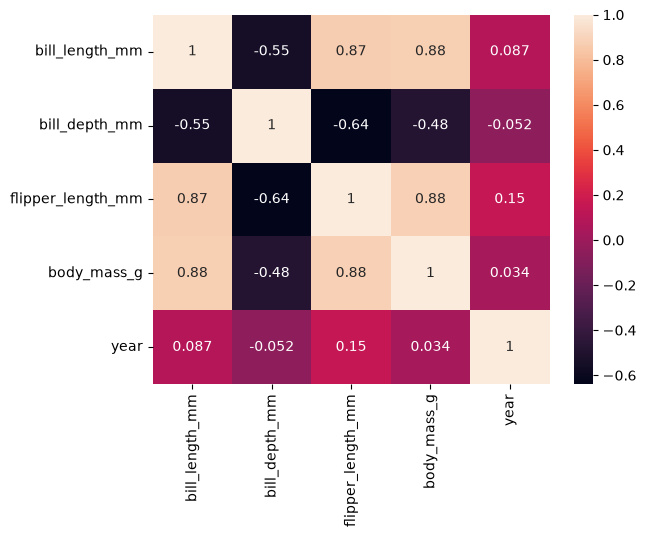

In [141]:
sns.heatmap(d.corr(numeric_only=True), annot=True)
plt.show()

---

### Train_Test_Split

In [143]:
x = d[['bill_length_mm' , 'bill_depth_mm', "flipper_length_mm", "body_mass_g", "year", 'island']]
y = d['species']

In [144]:
x_train , x_test , y_train , y_test = train_test_split(x,y, test_size=0.2, random_state=42)
print(x, '\n', y)

     bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  year  \
0              39.1           18.7              181.0       3750.0  2007   
1              39.5           17.4              186.0       3800.0  2007   
2              40.3           18.0              195.0       3250.0  2007   
3              36.7           19.3              193.0       3450.0  2007   
4              39.3           20.6              190.0       3650.0  2007   
..              ...            ...                ...          ...   ...   
269            47.2           13.7              214.0       4925.0  2009   
270            46.8           14.3              215.0       4850.0  2009   
271            50.4           15.7              222.0       5750.0  2009   
272            45.2           14.8              212.0       5200.0  2009   
273            49.9           16.1              213.0       5400.0  2009   

        island  
0    Torgersen  
1    Torgersen  
2    Torgersen  
3    Torgersen  
4 

### Label Encoding

In [145]:
le = LabelEncoder()
x_train['island'] = le.fit_transform(x_train['island'])
x_test['island'] = le.transform(x_test['island'])
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

### Model & Training

In [146]:
lr = LogisticRegression()
lr.fit(x_train, y_train)
pred = lr.predict(x_test)

### Model check

In [148]:
print("R2 Score: ", r2_score(y_test, pred))
print("Accuracy score: ", accuracy_score(y_test, pred))
print("\n Classification Report:\n ", classification_report(y_test, pred))

R2 Score:  1.0
Accuracy score:  1.0

 Classification Report:
                precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        25

    accuracy                           1.00        55
   macro avg       1.00      1.00      1.00        55
weighted avg       1.00      1.00      1.00        55

